<a href="https://colab.research.google.com/github/vkoul/dsbook/blob/main/book/PCA_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 <div class="alert alert-block alert-success">

 ## 📉 PCA — Dimensionality Reduction             
 👨‍🏫 **Vikesh K**  

 </div>

 💡  <span style='font-family:Georgia'>
    <font color= darkred> **"Clarity comes from doing."**
    </font> 💡   


## 📝Lab Agenda
    
We will cover:

* Why PCA?

* Applying PCA (PC = 2, PC = 1)

* Understanding Explained Variance

* Interpreting Components

* Choosing Number of Components

* Inverse Transformation & Reconstruction

## Importing the module and the data

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA

### Load the data

In [ ]:
iris_df = sns.load_dataset("iris")

In [ ]:
iris_df.shape

(150, 5)

**Values across the groups**

In [ ]:
iris_df.groupby('species').sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
25,5.0,3.0,1.6,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
13,4.3,3.0,1.1,0.1,setosa
10,5.4,3.7,1.5,0.2,setosa
72,6.3,2.5,4.9,1.5,versicolor
85,6.0,3.4,4.5,1.6,versicolor
52,6.9,3.1,4.9,1.5,versicolor
91,6.1,3.0,4.6,1.4,versicolor
82,5.8,2.7,3.9,1.2,versicolor


**Focusing only on the numerical values**

In [ ]:
iris_num = iris_df.select_dtypes(['float'])

## PC == 2

In [ ]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components = 2)

In [ ]:
transformed_df2 = pca2.fit_transform(iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

In [ ]:
# transformed_df2

**Converting the PCA data into Pandas dataframe and adding back the species details**

In [ ]:
transformed_df2_pd = pd.DataFrame(transformed_df2)
transformed_df2_pd
transformed_df2_pd = transformed_df2_pd.join(iris_df['species'])
transformed_df2_pd.head(2)

,0,1,species
0,-2.684126,0.319397,setosa
1,-2.714142,-0.177001,setosa


**Rename column names**

In [ ]:
transformed_df2_pd.columns = ['pc1', 'pc2', 'species']

In [ ]:
transformed_df2_pd.groupby('species').sample(2)

,pc1,pc2,species
27,-2.562320,0.367719,setosa
33,-2.598737,1.093146,setosa
85,0.806858,0.194182,versicolor
77,1.557802,0.267495,versicolor
136,2.144243,0.140064,virginica
124,2.275431,0.334991,virginica


**Check the correlations between the components**

In [ ]:
transformed_df2_pd[['pc1', 'pc2']].corr().round(6)

,pc1,pc2
pc1,1.0,0.0
pc2,0.0,1.0


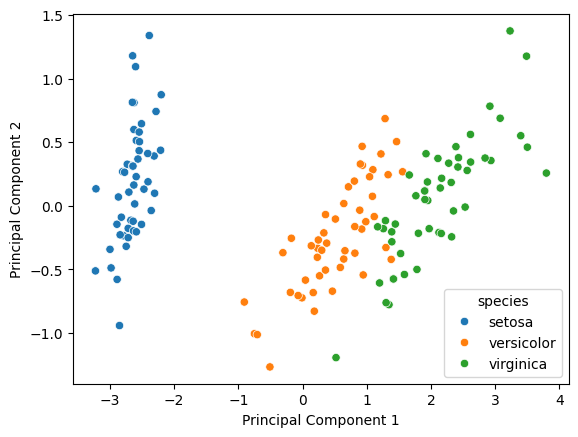

In [ ]:
sns.scatterplot(transformed_df2_pd, x = 'pc1', y = 'pc2', hue = transformed_df2_pd['species']);
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2");

## PC = 1

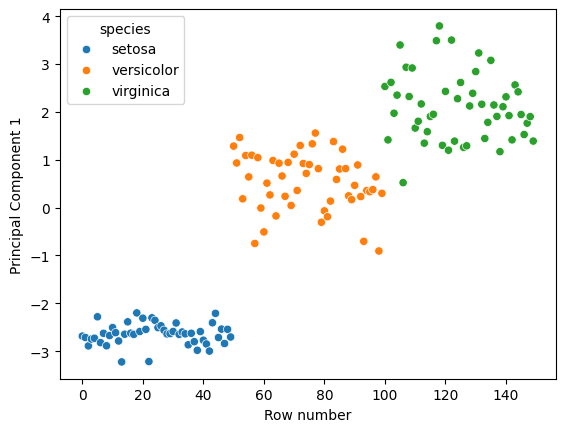

In [ ]:
pca1 = PCA(n_components = 1)

transformed_df1 = pca1.fit_transform(iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

transformed_df1_pd = pd.DataFrame(transformed_df1)
transformed_df1_pd = transformed_df1_pd.rename(columns = {0:"pc1"})

transformed_df1_pd = transformed_df1_pd.join(iris_df['species'])

sns.scatterplot(transformed_df1_pd, x = range(0, transformed_df1_pd.shape[0]), y = "pc1", hue = iris_df['species']);
plt.xlabel("Row number")
plt.ylabel("Principal Component 1");

In [ ]:
# transformed_df1_pd

In [ ]:
# transformed_df1_pd.groupby('species').sample(5)

### Understanding PCA further

### Explained Ratio

**We can extract the explained variance information on the transformed data**

In [ ]:
pca2.explained_variance_ratio_.round(3)

array([0.925, 0.053])

In [ ]:
pca2.explained_variance_ratio_.sum().round(3)

np.float64(0.978)

In [ ]:
information_lost = 1 - pca2.explained_variance_ratio_.sum()

print(f"Information lost was {information_lost :.2%}")

Information lost was 2.23%


**The above ratio means that first component explains around 92% of the variance and second one around 5%. And around 2.2% of information was lost**

### Components

Tells us correlation of the original features with the new features

In [ ]:
components = pca2.components_.round(2)
components

array([[ 0.36, -0.08,  0.86,  0.36],
       [ 0.66,  0.73, -0.17, -0.08]])

**The components tells us how much of the each original feature has contributed to the principal component**

In [ ]:
pd.DataFrame(components, columns=iris_num.columns, index=['PC1', 'PC2'])

,sepal_length,sepal_width,petal_length,petal_width
PC1,0.36,-0.08,0.86,0.36
PC2,0.66,0.73,-0.17,-0.08


### Deciding on the number of components

This essentially depends on how much information loss are you willing to accept. There is trade-off between features and the information loss.

**Ideally retain atleast 95% of the original variance**

**General way**

In [ ]:
pca_test = PCA(n_components = 0.6) # retain components to explain 60% of the variance in the data

pca_test.fit(iris_num)

len(pca_test.components_)

1

**Testing for the different values of explained variance**

In [ ]:
for i in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.96, 0.97, 0.98, 0.99]:
    pca_test = PCA(n_components = i)
    pca_test.fit(iris_num)
    count = len(pca_test.components_)

    print(f"for a minimum explained variance of {i}, we need {count} component(s)")

for a minimum explained variance of 0.4, we need 1 component(s)
for a minimum explained variance of 0.5, we need 1 component(s)
for a minimum explained variance of 0.6, we need 1 component(s)
for a minimum explained variance of 0.7, we need 1 component(s)
for a minimum explained variance of 0.8, we need 1 component(s)
for a minimum explained variance of 0.9, we need 1 component(s)
for a minimum explained variance of 0.96, we need 2 component(s)
for a minimum explained variance of 0.97, we need 2 component(s)
for a minimum explained variance of 0.98, we need 3 component(s)
for a minimum explained variance of 0.99, we need 3 component(s)


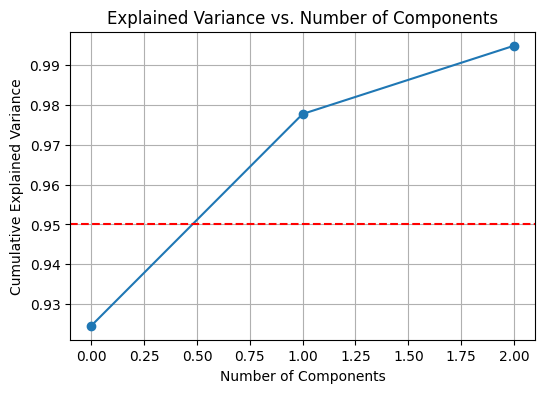

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca_test.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title('Explained Variance vs. Number of Components')
plt.show()

**Plotting the relationship between components and explained ratio**

In [ ]:
pca2.explained_variance_ratio_

array([0.92461872, 0.05306648])

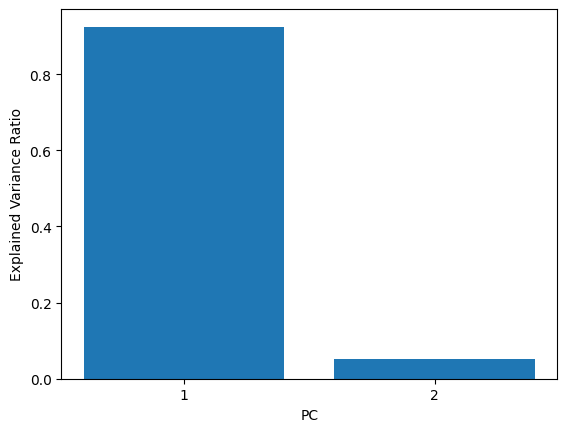

In [ ]:
x_values = np.arange(len(pca2.explained_variance_ratio_)) + 1  # Principal component indices (starting from 1)

# Plot a bar chart of explained variance ratio
plt.bar(x_values, pca2.explained_variance_ratio_)
plt.xticks(x_values);

plt.xlabel("PC")
plt.ylabel("Explained Variance Ratio");

### Inverse Transformation

Allows us to go back from the principal components to the original features

In [ ]:
iris_num.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Doing Inverse Transformation**

In [ ]:
pd.DataFrame(pca2.inverse_transform(transformed_df2).round(1)).head(5)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.7,3.2,1.5,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.1,3.5,1.4,0.2
